# Data analysis

This document provides a data analysis of a dataset containing pre- and postcollisional particle velocities generated by Classical Trajectory Calculations (CTC). The CTC simulation Fortran90 code was developed by professor Aldo Frezzoti from Politecnico di Milano.

## Dataset Variables

The columns in O2O2_collisions.csv represent the following variables:

| Column | Variable |
|--------|----------|
| 0 | v1_in(1) |
| 1 | v1_in(2) |
| 2 | v1_in(3) |
| 3 | v2_in(1) |
| 4 | v2_in(2) |
| 5 | v2_in(3) |
| 6 | omega1_in(1) |
| 7 | omega1_in(2) |
| 8 | omega1_in(3) |
| 9 | omega2_in(1) |
| 10 | omega2_in(2) |
| 11 | omega2_in(3) |
| 12 | v1_out(1) |
| 13 | v1_out(2) |
| 14 | v1_out(3) |
| 15 | v2_out(1) |
| 16 | v2_out(2) |
| 17 | v2_out(3) |
| 18 | omega1_out(1) |
| 19 | omega1_out(2) |
| 20 | omega1_out(3) |
| 21 | omega2_out(1) |
| 22 | omega2_out(2) |
| 23 | omega2_out(3) |

## Histograms

amount of datapoints: 400000


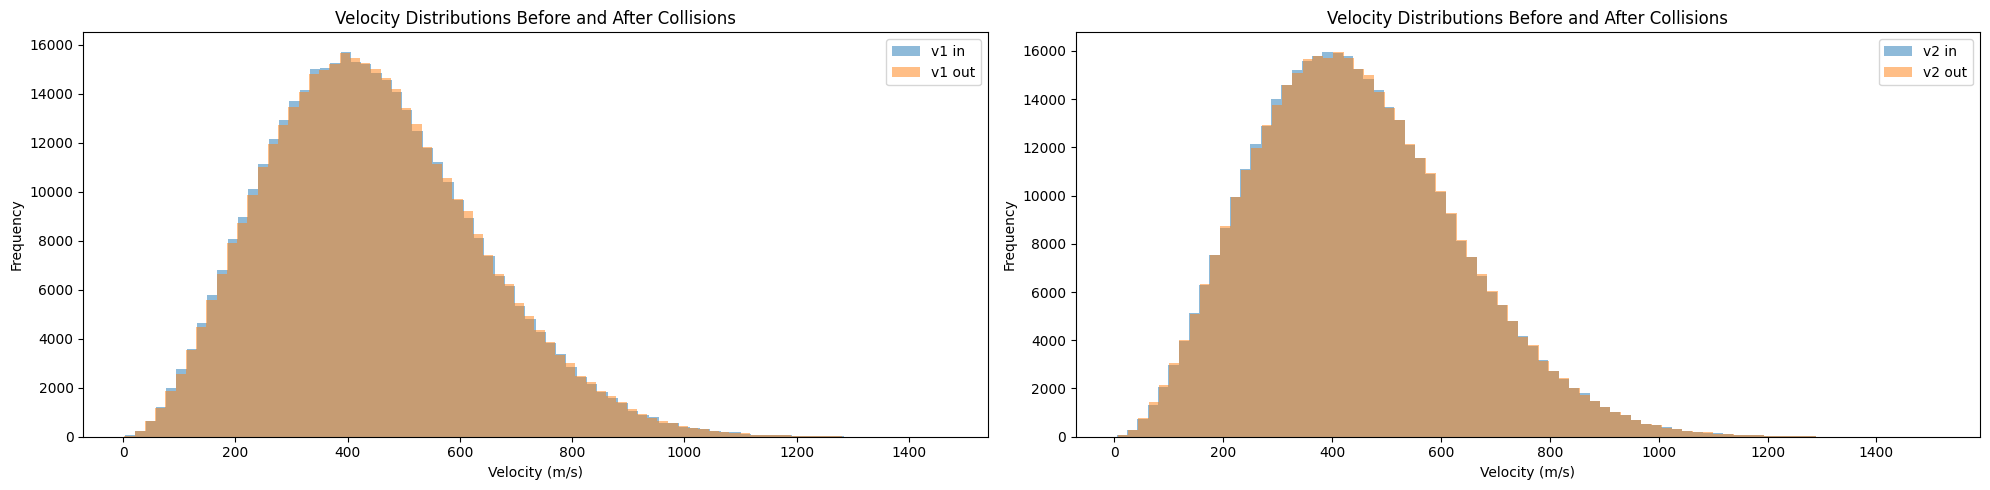

In [27]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('Run/O2O2_collisions.csv', delimiter=',')

print("amount of datapoints:", data.shape[0])

v1_in = np.sqrt(data[:,0]**2 + data[:,1]**2 + data[:,2]**2)
v1_out = np.sqrt(data[:,12]**2 + data[:,13]**2 + data[:,14]**2)

v2_in = np.sqrt(data[:,3]**2 + data[:,4]**2 + data[:,5]**2)
v2_out = np.sqrt(data[:,15]**2 + data[:,16]**2 + data[:,17]**2)

nr_bins = 80

fig, ax = plt.subplots(1,2, figsize=(20,5))
ax[0].hist(v1_in, bins=nr_bins, alpha=0.5, label='v1 in')
ax[0].hist(v1_out, bins=nr_bins, alpha=0.5, label='v1 out')
ax[0].set_xlabel('Velocity (m/s)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Velocity Distributions Before and After Collisions')
ax[0].legend()

ax[1].hist(v2_in, bins=nr_bins, alpha=0.5, label='v2 in')
ax[1].hist(v2_out, bins=nr_bins, alpha=0.5, label='v2 out')
ax[1].set_xlabel('Velocity (m/s)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Velocity Distributions Before and After Collisions')
ax[1].legend()
plt.tight_layout()

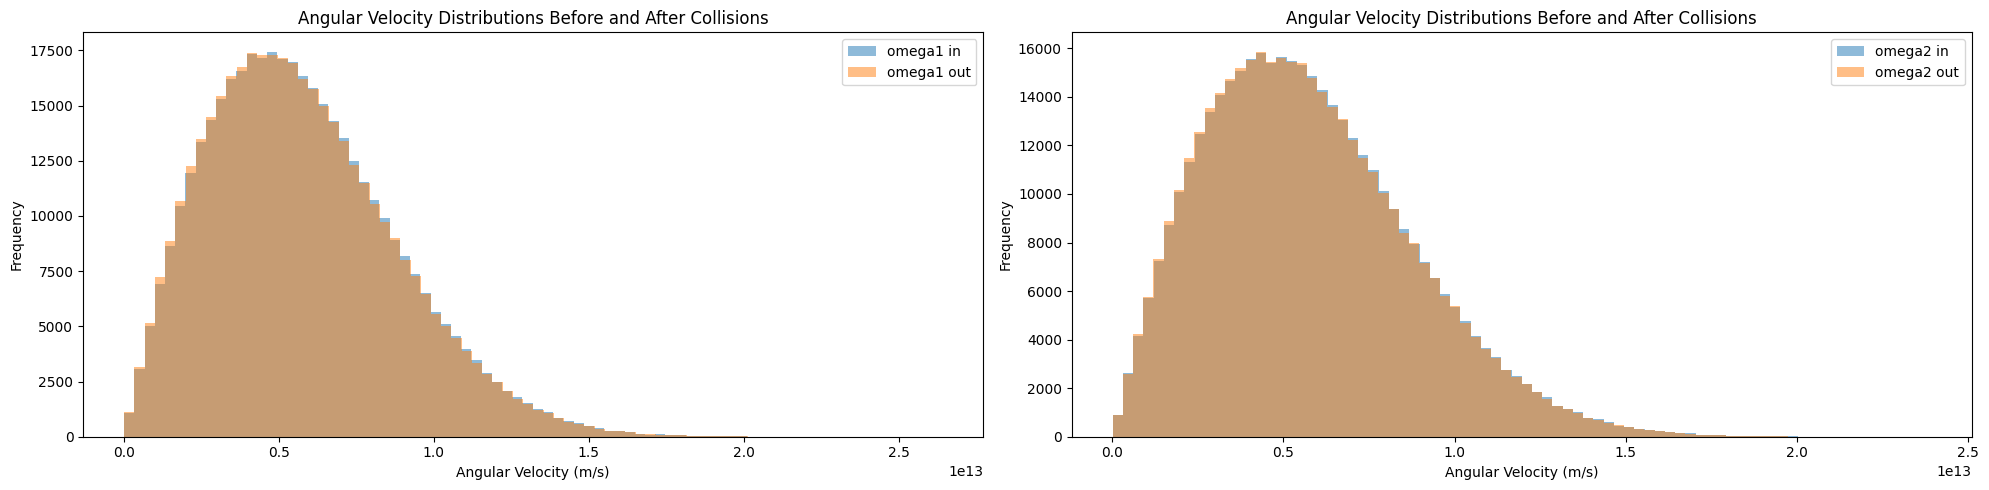

In [28]:
omega1_in = np.sqrt(data[:,6]**2 + data[:,7]**2 + data[:,8]**2)
omega1_out = np.sqrt(data[:,18]**2 + data[:,19]**2 + data[:,20]**2)

omega2_in = np.sqrt(data[:,9]**2 + data[:,10]**2 + data[:,11]**2)
omega2_out = np.sqrt(data[:,21]**2 + data[:,22]**2 + data[:,23]**2)

fig, ax = plt.subplots(1,2, figsize=(20,5))
ax[0].hist(omega1_in, bins=nr_bins, alpha=0.5, label='omega1 in')
ax[0].hist(omega1_out, bins=nr_bins, alpha=0.5, label='omega1 out')
ax[0].set_xlabel('Angular Velocity (m/s)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Angular Velocity Distributions Before and After Collisions')
ax[0].legend()

ax[1].hist(omega2_in, bins=nr_bins, alpha=0.5, label='omega2 in')
ax[1].hist(omega2_out, bins=nr_bins, alpha=0.5, label='omega2 out')
ax[1].set_xlabel('Angular Velocity (m/s)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Angular Velocity Distributions Before and After Collisions')
ax[1].legend()
plt.tight_layout()

It seems as though the distribution of pre- and post-collisional velocities are very similar, as shown in the histograms below. On top of that, the distributions seem normally distributed but with a long right tail, this could indicate a log-normal distribution. Further analysis is required to confirm this.

## Scattering plots for velocity components

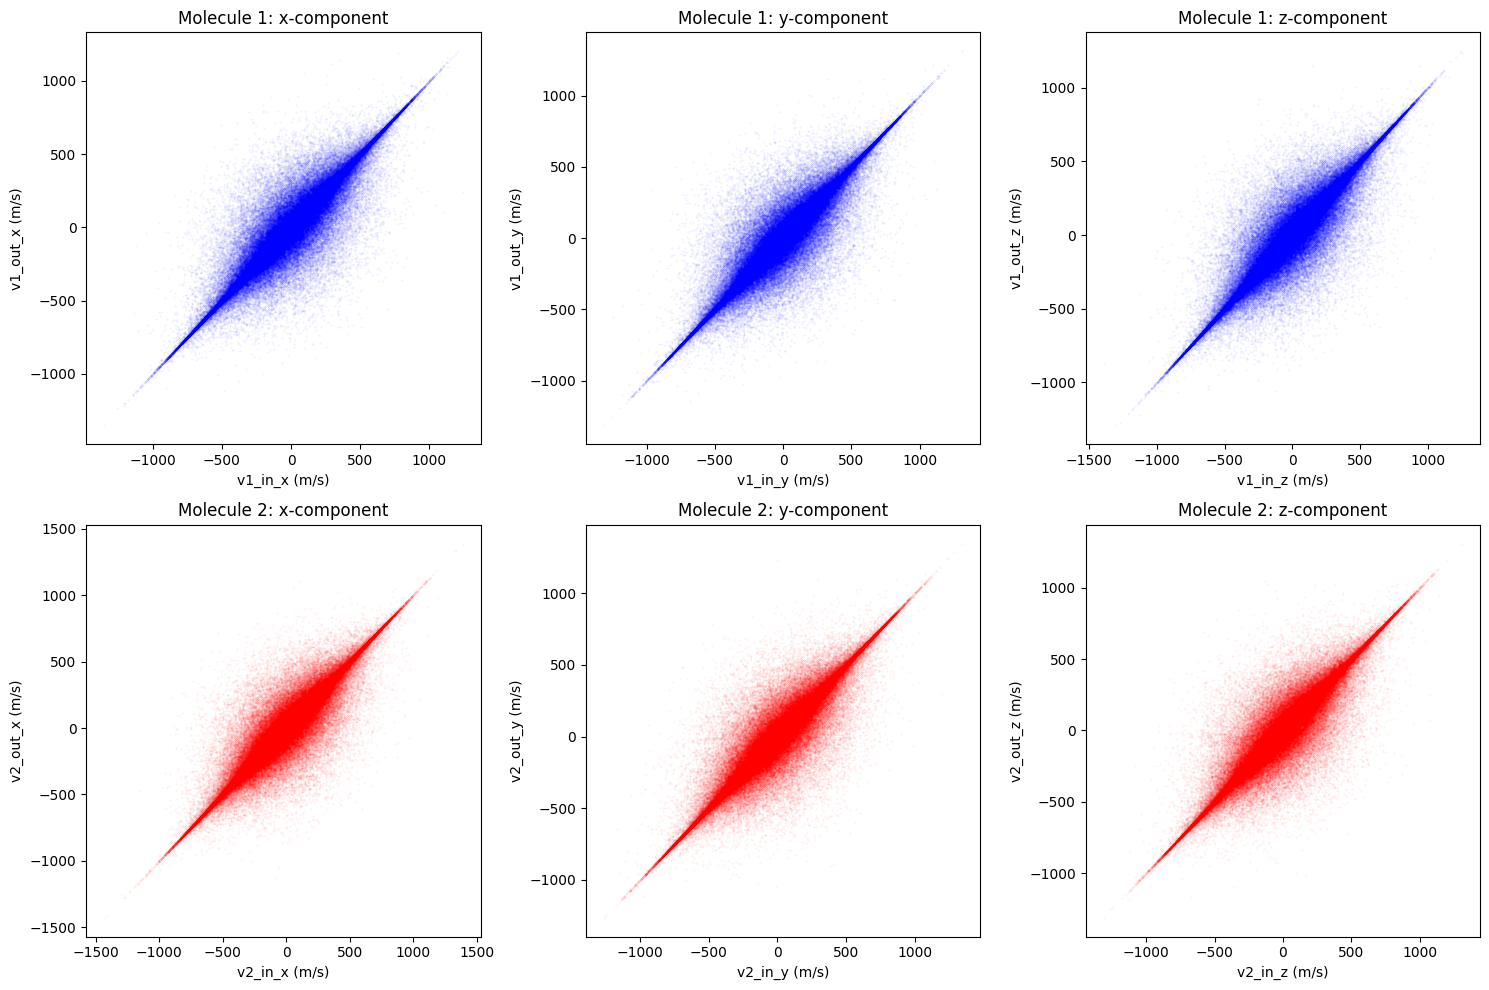

In [29]:
dotsize = 0.1
alpha = 0.1

# Translational velocity
fig, ax = plt.subplots(2,3, figsize=(15,10))
ax[0,0].scatter(data[:,0], data[:,12], alpha=0.1, color='blue', s=dotsize)
ax[0,0].set_xlabel('v1_in_x (m/s)')
ax[0,0].set_ylabel('v1_out_x (m/s)')
ax[0,0].set_title('Molecule 1: x-component')

ax[0,1].scatter(data[:,1], data[:,13], alpha=0.1, color='blue', s=dotsize)
ax[0,1].set_xlabel('v1_in_y (m/s)')
ax[0,1].set_ylabel('v1_out_y (m/s)')
ax[0,1].set_title('Molecule 1: y-component')

ax[0,2].scatter(data[:,2], data[:,14], alpha=0.1, color='blue', s=dotsize)
ax[0,2].set_xlabel('v1_in_z (m/s)')
ax[0,2].set_ylabel('v1_out_z (m/s)')
ax[0,2].set_title('Molecule 1: z-component')

ax[1,0].scatter(data[:,3], data[:,15], alpha=0.1, color='red', s=dotsize)
ax[1,0].set_xlabel('v2_in_x (m/s)')
ax[1,0].set_ylabel('v2_out_x (m/s)')
ax[1,0].set_title('Molecule 2: x-component')

ax[1,1].scatter(data[:,4], data[:,16], alpha=0.1, color='red', s=dotsize)
ax[1,1].set_xlabel('v2_in_y (m/s)')
ax[1,1].set_ylabel('v2_out_y (m/s)')
ax[1,1].set_title('Molecule 2: y-component')

ax[1,2].scatter(data[:,5], data[:,17], alpha=0.1, color='red', s=dotsize)
ax[1,2].set_xlabel('v2_in_z (m/s)')
ax[1,2].set_ylabel('v2_out_z (m/s)')
ax[1,2].set_title('Molecule 2: z-component')

plt.tight_layout()

## Interval analysis

Here we analyze the output velocity distributions in intervals of input velocities. This way we can discover if the input velocities have an effect on the output velocity distributions. If there is no effect, the output velocity distributions should remain the same for all input velocity intervals and we could model the scattering kernel with a single distribution. However, if there is an effect, we might need to model the scattering kernel with multiple distributions depending on the input velocity.

In [30]:
import pandas as pd
velocity_intervals = np.linspace(-1000, 1000, 21)
distribution_params = pd.DataFrame(index=range(20), columns=['interval', 'mean_x', 'std_x', 'mean_y', 'std_y', 'mean_z', 'std_z'])


for i in range(20):
    v_min = velocity_intervals[i]
    v_max = velocity_intervals[i+1]
    
    mask = (data[:,0] >= v_min) & (data[:,0] < v_max)
    distribution_params.at[i, 'std_x'] = np.std(data[mask,12])
    distribution_params.at[i, 'mean_x'] = np.mean(data[mask,12])

    mask = (data[:,1] >= v_min) & (data[:,1] < v_max)
    distribution_params.at[i, 'std_y'] = np.std(data[mask,13])
    distribution_params.at[i, 'mean_y'] = np.mean(data[mask,13])

    mask = (data[:,2] >= v_min) & (data[:,2] < v_max)
    distribution_params.at[i, 'std_z'] = np.std(data[mask,14])
    distribution_params.at[i, 'mean_z'] = np.mean(data[mask,14])

    distribution_params.at[i, 'interval'] = f"{v_min} to {v_max}"
distribution_params

,interval,mean_x,std_x,mean_y,std_y,mean_z,std_z
0,-1000.0 to -900.0,-904.114101,142.891056,-898.749798,160.541616,-898.934769,161.980307
1,-900.0 to -800.0,-818.149432,116.833114,-817.756626,114.731962,-815.78573,116.899517
2,-800.0 to -700.0,-713.392313,122.077067,-710.529877,138.292017,-711.417745,121.731086
3,-700.0 to -600.0,-615.342855,115.677304,-615.601084,117.989832,-617.625883,115.53958
4,-600.0 to -500.0,-520.022666,105.524287,-518.4336,112.227002,-520.46218,105.610913
5,-500.0 to -400.0,-424.920754,99.483161,-423.986633,100.266164,-423.552908,103.850332
6,-400.0 to -300.0,-329.190924,93.447426,-328.934113,96.131538,-329.274489,93.289579
7,-300.0 to -200.0,-234.030971,90.158277,-234.495049,89.90103,-235.128968,89.769825
8,-200.0 to -100.0,-141.473726,85.528689,-140.291234,84.412948,-140.045533,86.874301
9,-100.0 to 0.0,-45.865703,83.920286,-46.651894,85.080094,-46.859014,85.376911


It seems both the mean and standard deviation of the output velocities vary with the input velocity intervals, indicating that the input velocities do have an effect on the output velocity distributions. Therefore, it may be necessary to model the scattering kernel with multiple distributions based on the input velocity intervals. A good way to do this is using a Mixture Density Network (MDN), which takes input features and predicts parameters of a mixture of distributions, allowing for flexible modeling of complex relationships between input and output variables.

The scattering plots below show the relationship between pre-collisional and post-collisional velocities for the velocity intervals of molecule 1. Each plot corresponds to a specific range of pre-collisional velocities for a specific velocity component (x,y,z) of molecule 1, allowing us to observe how the collision dynamics vary with initial conditions. These plots visually demonstrate the effect of input velocities on output velocity distributions. The mean of the output velocities is always close to the mean of the input velocities in each interval, but the spread (standard deviation) of the output velocities changes with the input velocity intervals, where higher input velocities tend to result in larger spreads (standard deviation) of output velocities.

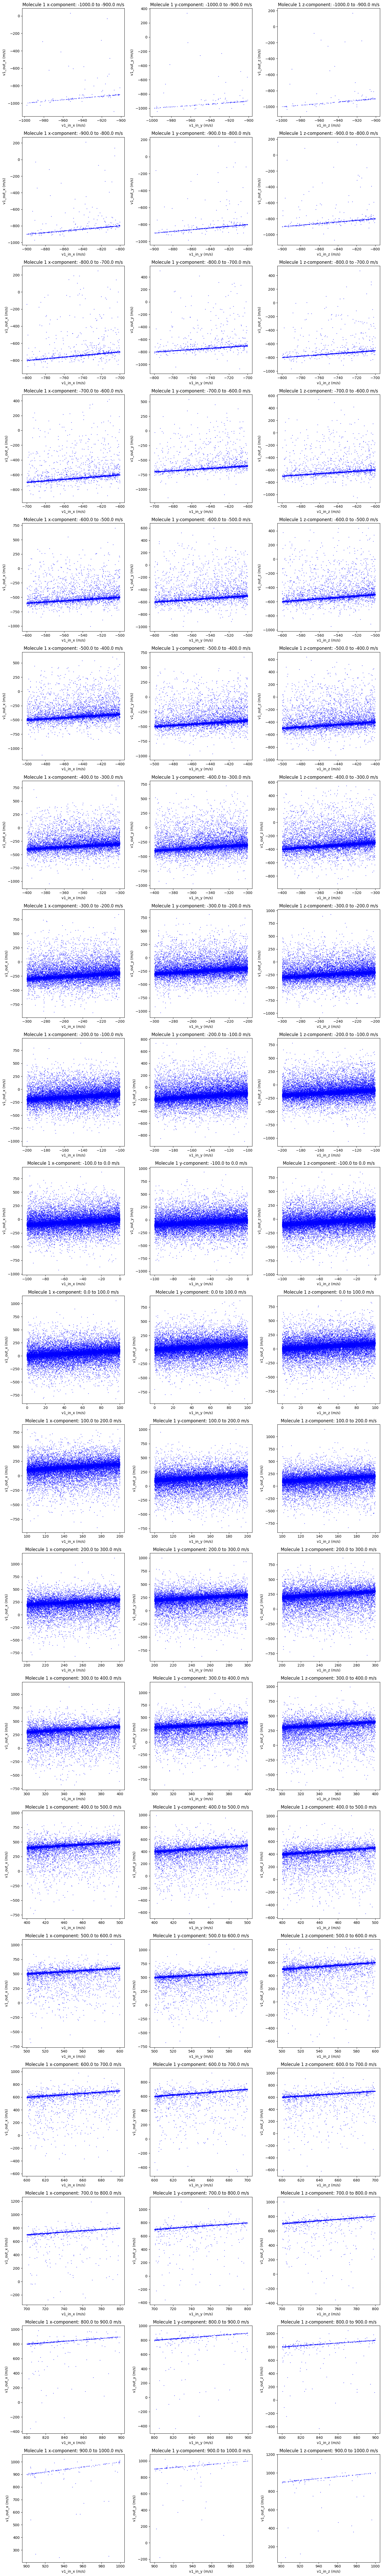

In [31]:
fig, ax = plt.subplots(20,3, figsize=(15,100))
alpha = 0.5
dotsize = 1

for i in range(20):
    v_min = velocity_intervals[i]
    v_max = velocity_intervals[i+1]
    
    mask = (data[:,0] >= v_min) & (data[:,0] < v_max)
    ax[i,0].scatter(data[mask,0], data[mask,12], alpha=alpha, color='blue', s=dotsize)
    ax[i,0].set_xlabel('v1_in_x (m/s)')
    ax[i,0].set_ylabel('v1_out_x (m/s)')
    ax[i,0].set_title(f'Molecule 1 x-component: {v_min} to {v_max} m/s')
    
    mask = (data[:,1] >= v_min) & (data[:,1] < v_max)
    ax[i,1].scatter(data[mask,1], data[mask,13], alpha=alpha, color='blue', s=dotsize)
    ax[i,1].set_xlabel('v1_in_y (m/s)')
    ax[i,1].set_ylabel('v1_out_y (m/s)')
    ax[i,1].set_title(f'Molecule 1 y-component: {v_min} to {v_max} m/s')
    
    mask = (data[:,2] >= v_min) & (data[:,2] < v_max)
    ax[i,2].scatter(data[mask,2], data[mask,14], alpha=alpha, color='blue', s=dotsize)
    ax[i,2].set_xlabel('v1_in_z (m/s)')
    ax[i,2].set_ylabel('v1_out_z (m/s)')
    ax[i,2].set_title(f'Molecule 1 z-component: {v_min} to {v_max} m/s')

plt.tight_layout()

## Compare with hydrogen data

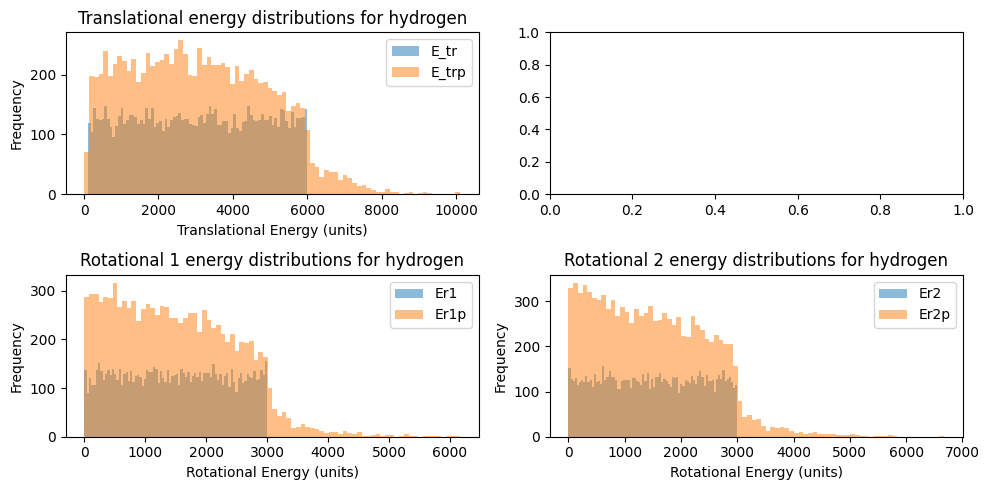

In [32]:
hydrogen_data = np.loadtxt('Run/H2H2_collisions_benjamin.csv', delimiter=',', skiprows=1)

Etr = hydrogen_data[:,1]
Etrp = hydrogen_data[:,4]

fig, ax = plt.subplots(2,2, figsize=(10,5))
ax[0,0].hist(Etr, bins=80, alpha=0.5, label='E_tr')
ax[0,0].hist(Etrp, bins=80, alpha=0.5, label='E_trp')
ax[0,0].set_xlabel('Translational Energy (units)')
ax[0,0].set_ylabel('Frequency')
ax[0,0].set_title('Translational energy distributions for hydrogen')
ax[0,0].legend()

Er1 = hydrogen_data[:,2]
Er1p = hydrogen_data[:,5]
Er2 = hydrogen_data[:,3]
Er2p = hydrogen_data[:,6]

ax[1,0].hist(Er1, bins=80, alpha=0.5, label='Er1')
ax[1,0].hist(Er1p, bins=80, alpha=0.5, label='Er1p')
ax[1,0].set_xlabel('Rotational Energy (units)')
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_title('Rotational 1 energy distributions for hydrogen')
ax[1,0].legend()

ax[1,1].hist(Er2, bins=80, alpha=0.5, label='Er2')
ax[1,1].hist(Er2p, bins=80, alpha=0.5, label='Er2p')
ax[1,1].set_xlabel('Rotational Energy (units)')
ax[1,1].set_ylabel('Frequency')
ax[1,1].set_title('Rotational 2 energy distributions for hydrogen')
ax[1,1].legend()
plt.tight_layout()